# Aerial Cactus CNN Project

In this project, our primary goal is to train a machine learning algorithm capable of detecting the presence of columnar cacti (Neobuxbaumia tetetzo) in aerial imagery.

<img src='https://cdn.backpacker.com/wp-content/uploads/2022/09/joshua-tree-stars.jpg?auto=webp&width=3840&quality=75&fit=cover' width='750'>

In [1]:
#Libraries
import numpy as np
import pandas as pd
import os
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# EDA

In [3]:
import zipfile
import os

# Extract train.zip and test.zip into the current directory
with zipfile.ZipFile('train.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

with zipfile.ZipFile('test.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Zip files extracted successfully!")

Zip files extracted successfully!


In [8]:
import os
import pandas as pd

# Define paths relative to your local Jupyter notebook directory
train_dir = 'train/'
test_dir = 'test/'

# Load the training CSV file from your local folder
train_df = pd.read_csv('train.csv')

print("CSV file loaded successfully!")
print(train_df.head())

CSV file loaded successfully!
                                     id  has_cactus
0  0004be2cfeaba1c0361d39e2b000257b.jpg           1
1  000c8a36845c0208e833c79c1bffedd1.jpg           1
2  000d1e9a533f62e55c289303b072733d.jpg           1
3  0011485b40695e9138e92d0b3fb55128.jpg           1
4  0014d7a11e90b62848904c1418fc8cf2.jpg           1


In [9]:
img_list1 = [os.path.join(train_path, img_id) for img_id in train_df['id']]
label_list1 = list(train_df['has_cactus'])

In [10]:
df = pd.DataFrame()
df['image'] = img_list1
df['label'] = label_list1

In [11]:
test_filenames = os.listdir(test_dir)
test_df = pd.DataFrame({
    'id': test_filenames})

In [12]:
df.head()

,image,label
0,/kaggle/working/train/0004be2cfeaba1c0361d39e2...,1
1,/kaggle/working/train/000c8a36845c0208e833c79c...,1
2,/kaggle/working/train/000d1e9a533f62e55c289303...,1
3,/kaggle/working/train/0011485b40695e9138e92d0b...,1
4,/kaggle/working/train/0014d7a11e90b62848904c14...,1


In [13]:
df.shape

(17500, 2)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   17500 non-null  object
 1   label   17500 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 273.6+ KB


In [15]:
df.isnull().sum()

image    0
label    0
dtype: int64

In [16]:
df['label'] = df['label'].astype(str)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   17500 non-null  object
 1   label   17500 non-null  object
dtypes: object(2)
memory usage: 273.6+ KB


In [18]:
df['label'].value_counts()

label
1    13136
0     4364
Name: count, dtype: int64

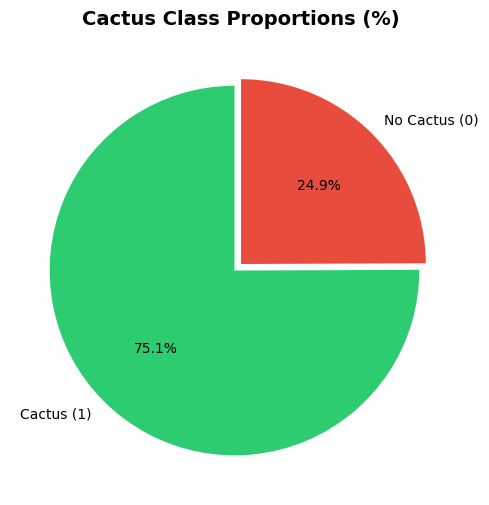

In [19]:
import matplotlib.pyplot as plt

# Get class counts
counts = train_df['has_cactus'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, 
        labels=['Cactus (1)', 'No Cactus (0)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#2ecc71', '#e74c3c'], 
        explode=(0.05, 0))

plt.title('Cactus Class Proportions (%)', fontsize=14, fontweight='bold')
plt.show()

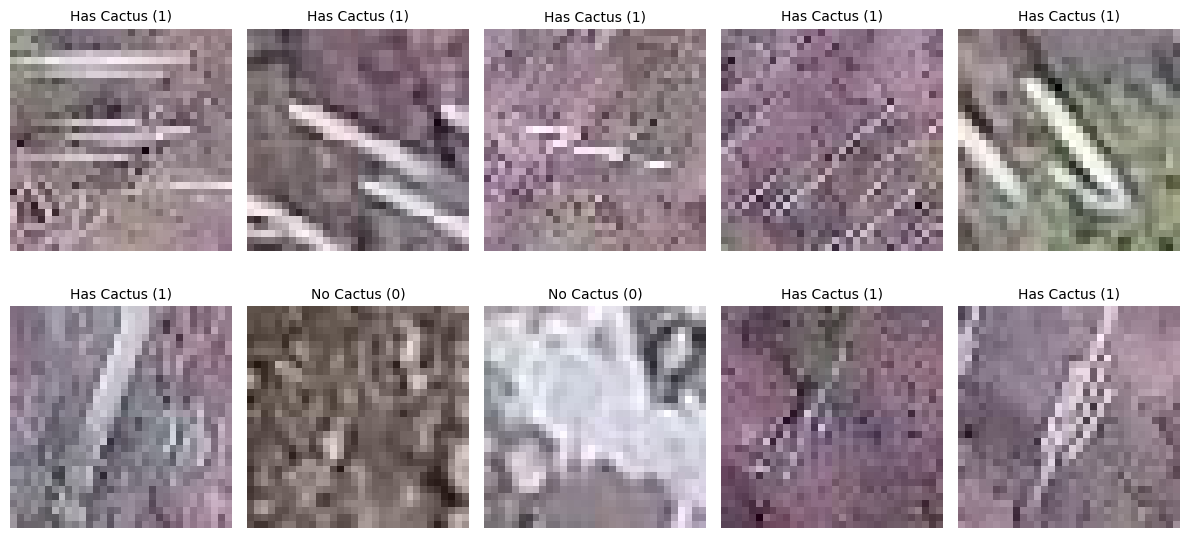

In [21]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for k, ax in enumerate(axes.ravel()):
    img_path = os.path.join('train', train_df.iloc[k]['id'])
    label = train_df.iloc[k]['has_cactus']
    
    img = plt.imread(img_path)
    ax.imshow(img)
    
    status = "Has Cactus (1)" if label == 1 else "No Cactus (0)"
    ax.set_title(status, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
test_df.head()

,id
0,000940378805c44108d287872b2f04ce.jpg
1,0017242f54ececa4512b4d7937d1e21e.jpg
2,001ee6d8564003107853118ab87df407.jpg
3,002e175c3c1e060769475f52182583d0.jpg
4,0036e44a7e8f7218e9bc7bf8137e4943.jpg


In [23]:
test_df.shape

(4000, 1)

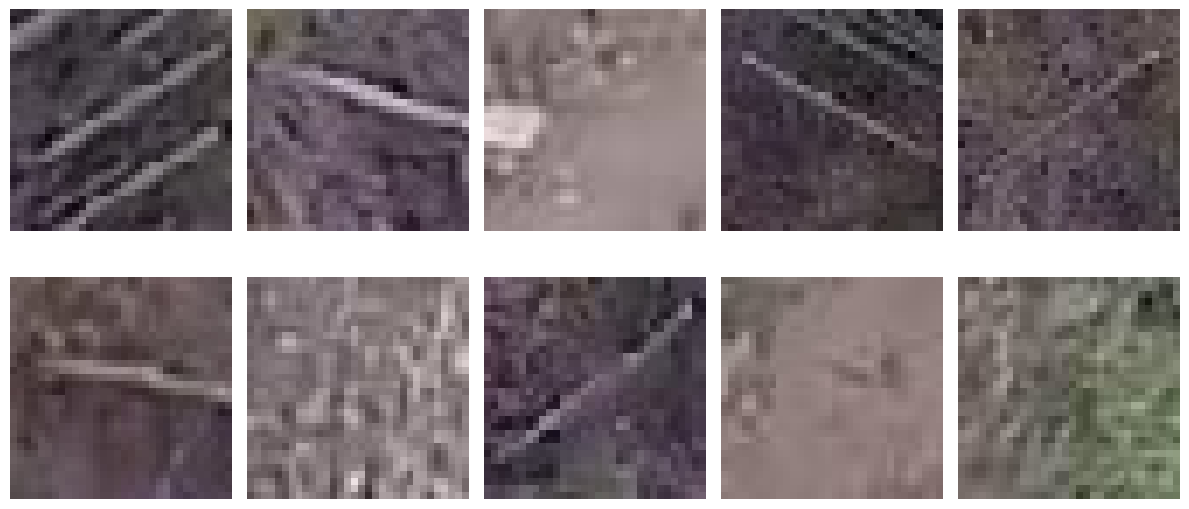

In [24]:
import os, matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for ax, img_name in zip(axes.flat, test_df['id'].sample(10)):
    ax.imshow(plt.imread(os.path.join(test_dir, img_name)))
    ax.axis('off')

plt.tight_layout()
plt.show()

### Data Processing

In [29]:
import numpy as np
import pandas as pd
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load data
df = pd.read_csv('train.csv')

# 2. Compute Class Weights
unique_classes = np.sort(df['has_cactus'].unique())
class_weights_arr = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=df['has_cactus']
)
weights_dict = {cls: weight for cls, weight in zip(unique_classes, class_weights_arr)}

# 3. Train - Validation Split (80% / 20%)
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['has_cactus']
)

# Convert labels to string format for Keras binary class mode
train_df['has_cactus'] = train_df['has_cactus'].astype(str)
val_df['has_cactus'] = val_df['has_cactus'].astype(str)

# 4. Data Generators
IMG_SIZE = (32, 32)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='train/',         # Directory where images exist
    x_col="id",                # Correct filename column
    y_col="has_cactus",        # Correct target label column
    target_size=IMG_SIZE,      # Native size 32x32
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory='train/',        # Directory where images exist
    x_col="id",
    y_col="has_cactus",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 14000 validated image filenames belonging to 2 classes.
Found 3500 validated image filenames belonging to 2 classes.


### Modelling - ResNet50

In [30]:
inputs = Input(shape=(64, 64, 3))
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
loss='binary_crossentropy',
metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 70, 70, 3)         │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 32, 32, 64)        │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 32, 32, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 32, 32, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 34, 34, 64)        │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 16, 16, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 16, 16, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 16, 16, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 16, 16, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 16, 16, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 16, 16, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 16, 16, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 16, 16, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 16, 16, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Ensure class weight keys are formatted as integers for Keras model.fit()
weights_dict = {int(k): float(v) for k, v in weights_dict.items()}

# 1. Define Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    )
]

# 2. Train Model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=weights_dict
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 128s 577ms/step - accuracy: 0.8267 - loss: 0.3710 - val_accuracy: 0.9471 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9139 - loss: 0.2187 - val_accuracy: 0.9449 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9236 - loss: 0.1956 - val_accuracy: 0.9509 - val_loss: 0.1520 - learning_rate: 0.0010
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9321 - loss: 0.1780 - val_accuracy: 0.9594 - val_loss: 0.1090 - learning_rate: 0.0010
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9355 - loss: 0.1655 - val_accuracy: 0.9631 - val_loss: 0.1093 - learning_rate: 0.0010
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.9352 - loss: 0.1604 - val_accuracy: 0.9543 - val_loss: 0.1189 - learning_rate: 0.0010
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9403 -

In [35]:
history.history['accuracy'][-1]

0.971928596496582

In [36]:
model.save('cactus.keras')

### Model Interpretation¶

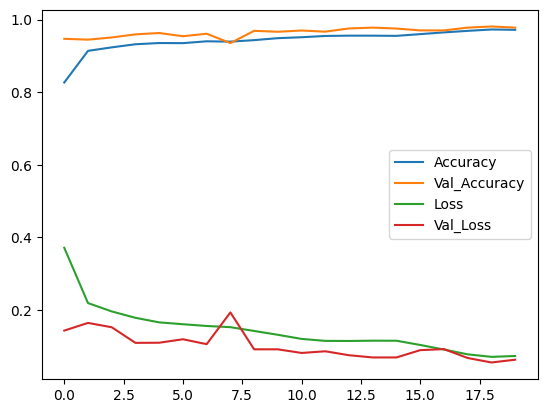

In [38]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend();

### Submission

In [39]:
#Test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(dataframe=test_df,
directory=test_dir,
x_col='id',
y_col=None,
class_mode=None,
shuffle=False,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE)

#Prediction
predictions = model.predict(test_generator)

Found 4000 validated image filenames.
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 407ms/step


In [40]:
#Submission 
submission_df = pd.DataFrame()
submission_df['id'] = test_filenames
submission_df['has_cactus'] = predictions.flatten() 
submission_df.to_csv('submission.csv', index=False)

### Fine-Tuning

In [41]:
base_model.trainable = True

model.compile(
optimizer=Adam(learning_rate=1e-5),
loss='binary_crossentropy',
metrics=['accuracy']
)

history_fine = model.fit(
train_generator,
epochs=15,
validation_data=val_generator,
callbacks=callbacks,
class_weight=weights_dict
)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9738 - loss: 0.0675 - val_accuracy: 0.9800 - val_loss: 0.0592 - learning_rate: 1.0000e-05
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.9759 - loss: 0.0631 - val_accuracy: 0.9806 - val_loss: 0.0545 - learning_rate: 1.0000e-05
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.9750 - loss: 0.0650 - val_accuracy: 0.9800 - val_loss: 0.0562 - learning_rate: 1.0000e-05
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9751 - loss: 0.0638 - val_accuracy: 0.9811 - val_loss: 0.0534 - learning_rate: 1.0000e-05
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.9769 - loss: 0.0614 - val_accuracy: 0.9800 - val_loss: 0.0580 - learning_rate: 1.0000e-05
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9746 - loss: 0.0633 - val_accuracy: 0.9789 - val_loss: 0.0603 - learning_rate: 1.0000e-05
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

In [42]:
history_fine.history['accuracy'][-1]

0.9763571619987488

In [43]:
tf.keras.models.save_model(model, "cactus2.keras")

In this project, we successfully implemented a Convolutional Neural Network (CNN) pipeline to automate the detection of *Neobuxbaumia tetetzo* cacti from low-resolution aerial thumbnail imagery. By applying strategic data augmentation, handling class imbalances through weighted loss, and training the model with adaptive learning rate callbacks, the model achieved high classification performance as measured by the ROC AUC evaluation metric.